In [1]:
!pip install textblob
!pip install wordcloud
!pip install nltk

   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   --------------------------------- ------ 524.3/625.0 kB 3.4 MB/s eta 0:00:01
   ---------------------------------------- 625.0/625.0 kB 3.0 MB/s  0:00:00


In [3]:
# Libraries Import :
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
import re
import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords')
nltk.download('punkt')

print("All libraries imported!")

All libraries imported!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\zerot\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\zerot\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [4]:
# Dataset make :
# Amazon Product Reviews Dataset
data = {
    'review': [
        "This product is absolutely amazing! Best purchase ever!",
        "Terrible quality, complete waste of money",
        "Good product but delivery was slow",
        "Excellent! Works perfectly as described",
        "Very disappointed with the quality",
        "Outstanding performance, highly recommend!",
        "Not worth the price, very cheap quality",
        "Great value for money, very satisfied",
        "Poor customer service, product broke after 2 days",
        "Fantastic product! Will buy again",
        "Average product, nothing special",
        "Worst purchase of my life, total scam",
        "Pretty good, meets expectations",
        "Superb quality, exceeded my expectations",
        "Okay product but overpriced",
        "Love this product! Works like a charm",
        "Horrible experience, never buying again",
        "Decent product for the price",
        "Absolutely love it! Perfect gift",
        "Very poor quality, broke immediately",
        "Good but could be better",
        "Excellent quality and fast delivery",
        "Not satisfied at all with this product",
        "Amazing product, great customer service",
        "Below average, expected much better",
        "Perfect! Exactly what I needed",
        "Cheap and breaks easily",
        "Very happy with my purchase",
        "Disappointing, does not work as advertised",
        "Best product in this price range!"
    ],
    'category': [
        'Electronics','Electronics','Electronics',
        'Electronics','Electronics',
        'Clothing','Clothing','Clothing',
        'Clothing','Clothing',
        'Books','Books','Books',
        'Books','Books',
        'Home','Home','Home',
        'Home','Home',
        'Sports','Sports','Sports',
        'Sports','Sports',
        'Beauty','Beauty','Beauty',
        'Beauty','Beauty'
    ]
}

df = pd.DataFrame(data)
print("Dataset created!")
print("Shape:", df.shape)
df.head()

Dataset created!
Shape: (30, 2)


,review,category
0,This product is absolutely amazing! Best purch...,Electronics
1,"Terrible quality, complete waste of money",Electronics
2,Good product but delivery was slow,Electronics
3,Excellent! Works perfectly as described,Electronics
4,Very disappointed with the quality,Electronics


In [5]:
# Sentiment Analysis :
def get_sentiment(text):
    analysis = TextBlob(text)
    polarity = analysis.sentiment.polarity
    if polarity > 0.1:
        return 'Positive'
    elif polarity < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

def get_polarity(text):
    return TextBlob(text).sentiment.polarity

def get_subjectivity(text):
    return TextBlob(text).sentiment.subjectivity

# Apply sentiment analysis
df['sentiment'] = df['review'].apply(get_sentiment)
df['polarity'] = df['review'].apply(get_polarity)
df['subjectivity'] = df['review'].apply(get_subjectivity)

print("Sentiment Analysis Complete!")
print("\nSentiment Distribution:")
print(df['sentiment'].value_counts())
print("\nSample Results:")
print(df[['review','sentiment','polarity']].head(10))

Sentiment Analysis Complete!

Sentiment Distribution:
sentiment
Positive    21
Negative     8
Neutral      1
Name: count, dtype: int64

Sample Results:
                                              review sentiment  polarity
0  This product is absolutely amazing! Best purch...  Positive  0.875000
1          Terrible quality, complete waste of money  Negative -0.366667
2                 Good product but delivery was slow  Positive  0.200000
3            Excellent! Works perfectly as described  Positive  1.000000
4                 Very disappointed with the quality  Negative -0.975000
5         Outstanding performance, highly recommend!  Positive  0.350000
6            Not worth the price, very cheap quality  Positive  0.185000
7              Great value for money, very satisfied  Positive  0.725000
8  Poor customer service, product broke after 2 days  Negative -0.400000
9                  Fantastic product! Will buy again  Positive  0.500000


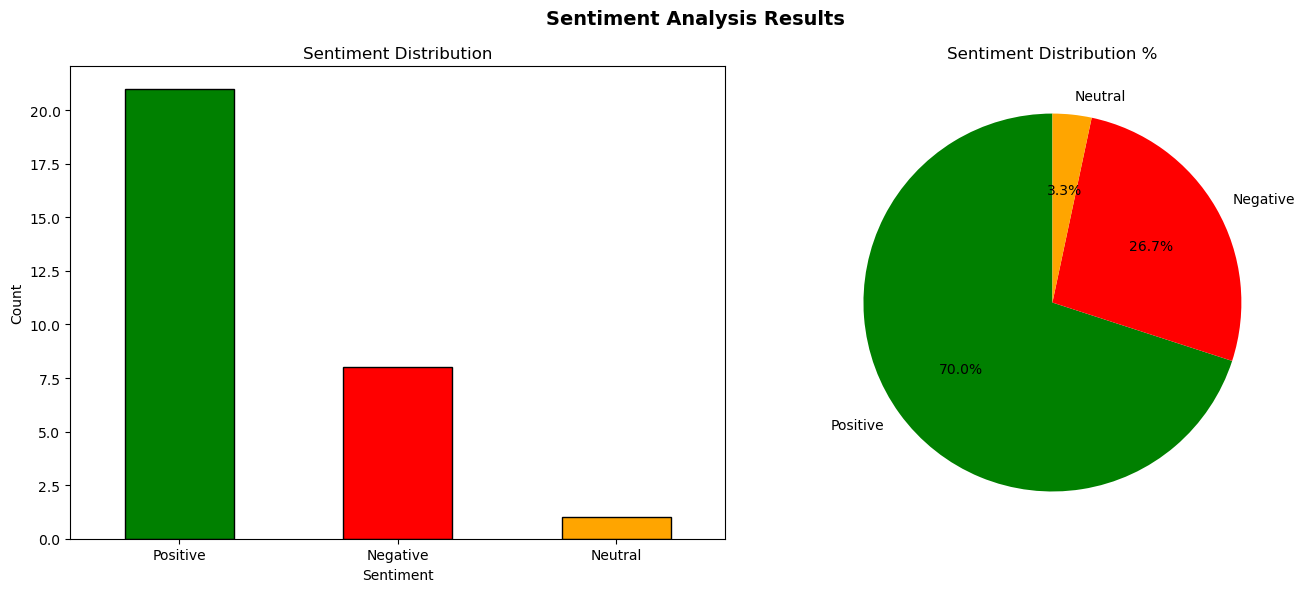

In [6]:
# Sentiment Distribution :
fig, axes = plt.subplots(1, 2, figsize=(14,6))
fig.suptitle('Sentiment Analysis Results',
             fontsize=14, fontweight='bold')

# Plot 1: Sentiment Count
colors = {'Positive':'green',
          'Negative':'red',
          'Neutral':'orange'}
sentiment_colors = [colors[s] for s in
                   df['sentiment'].value_counts().index]
df['sentiment'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=sentiment_colors,
    edgecolor='black')
axes[0].set_title('Sentiment Distribution')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

# Plot 2: Sentiment Pie Chart
df['sentiment'].value_counts().plot(
    kind='pie', ax=axes[1],
    colors=['green','red','orange'],
    autopct='%1.1f%%',
    startangle=90)
axes[1].set_title('Sentiment Distribution %')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('sentiment_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

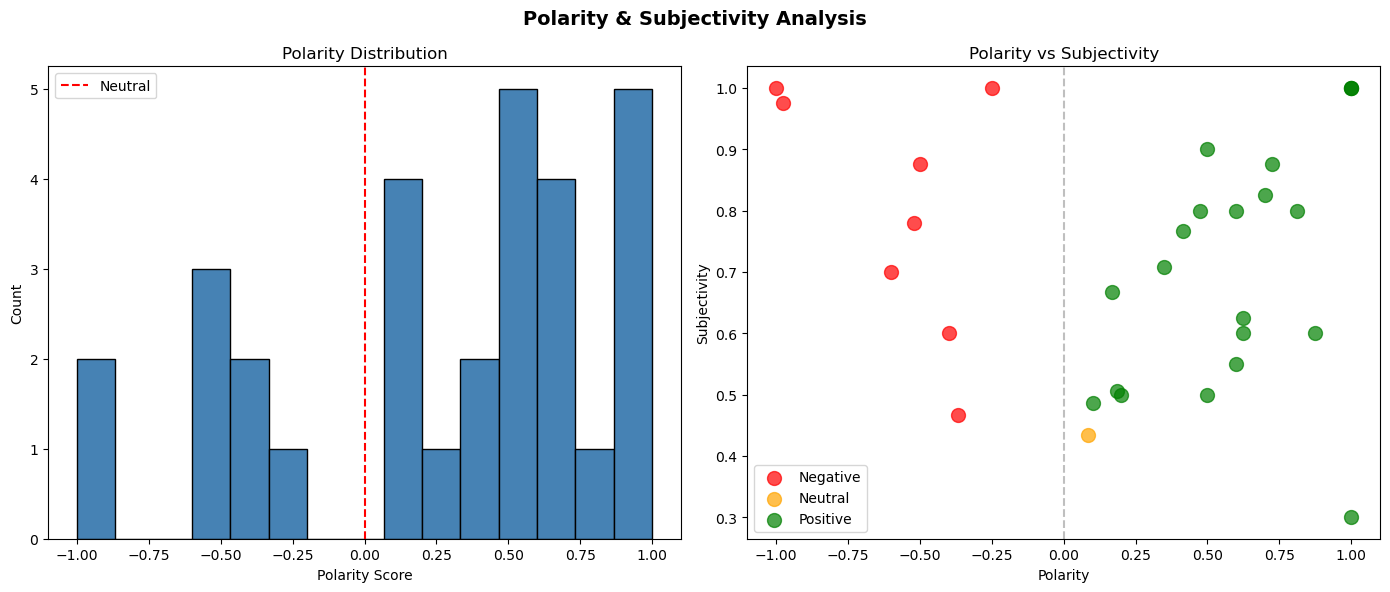

In [7]:
# Polarity & Subjectivity :
fig, axes = plt.subplots(1, 2, figsize=(14,6))
fig.suptitle('Polarity & Subjectivity Analysis',
             fontsize=14, fontweight='bold')

# Plot 1: Polarity Distribution
axes[0].hist(df['polarity'], bins=15,
             color='steelblue',
             edgecolor='black')
axes[0].set_title('Polarity Distribution')
axes[0].set_xlabel('Polarity Score')
axes[0].set_ylabel('Count')
axes[0].axvline(x=0, color='red',
                linestyle='--', label='Neutral')
axes[0].legend()

# Plot 2: Polarity vs Subjectivity
colors_map = {'Positive':'green',
              'Negative':'red',
              'Neutral':'orange'}
for sentiment, group in df.groupby('sentiment'):
    axes[1].scatter(group['polarity'],
                    group['subjectivity'],
                    label=sentiment,
                    color=colors_map[sentiment],
                    alpha=0.7, s=100)
axes[1].set_title('Polarity vs Subjectivity')
axes[1].set_xlabel('Polarity')
axes[1].set_ylabel('Subjectivity')
axes[1].legend()
axes[1].axvline(x=0, color='gray',
                linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('polarity_subjectivity.png',
            dpi=150, bbox_inches='tight')
plt.show()

<Figure size 1200x600 with 0 Axes>

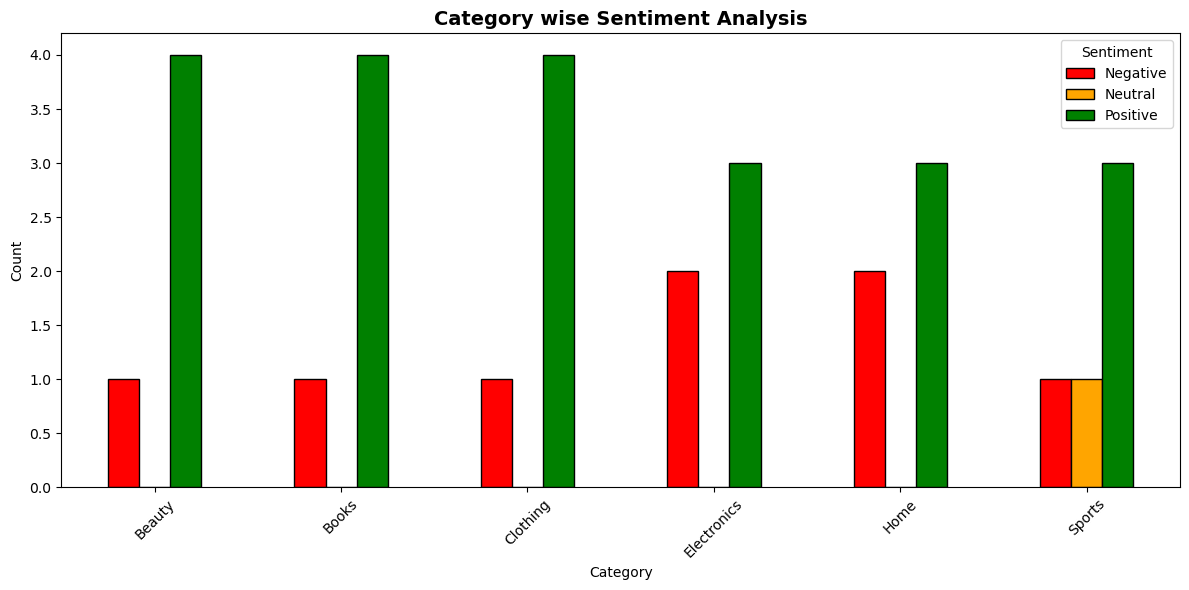

In [8]:
# Category wise Sentiment :
plt.figure(figsize=(12,6))
category_sentiment = pd.crosstab(
    df['category'], df['sentiment'])
category_sentiment.plot(
    kind='bar',
    color=['red','orange','green'],
    edgecolor='black',
    figsize=(12,6))
plt.title('Category wise Sentiment Analysis',
          fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.savefig('category_sentiment.png',
            dpi=150, bbox_inches='tight')
plt.show()

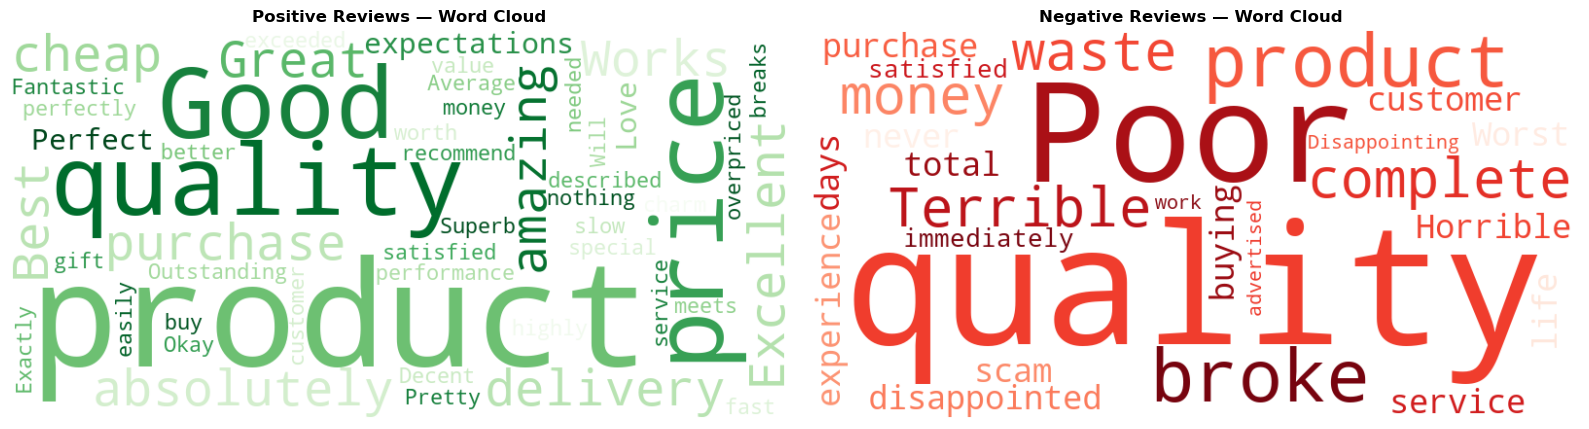

In [9]:
# Word Cloud :
# Positive reviews word cloud
positive_reviews = ' '.join(
    df[df['sentiment']=='Positive']['review'])
negative_reviews = ' '.join(
    df[df['sentiment']=='Negative']['review'])

fig, axes = plt.subplots(1, 2, figsize=(16,6))

# Positive Word Cloud
wordcloud_pos = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Greens',
    max_words=50).generate(positive_reviews)
axes[0].imshow(wordcloud_pos,
               interpolation='bilinear')
axes[0].set_title('Positive Reviews — Word Cloud',
                   fontsize=12, fontweight='bold')
axes[0].axis('off')

# Negative Word Cloud
wordcloud_neg = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Reds',
    max_words=50).generate(negative_reviews)
axes[1].imshow(wordcloud_neg,
               interpolation='bilinear')
axes[1].set_title('Negative Reviews — Word Cloud',
                   fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('wordclouds.png',
            dpi=150, bbox_inches='tight')
plt.show()

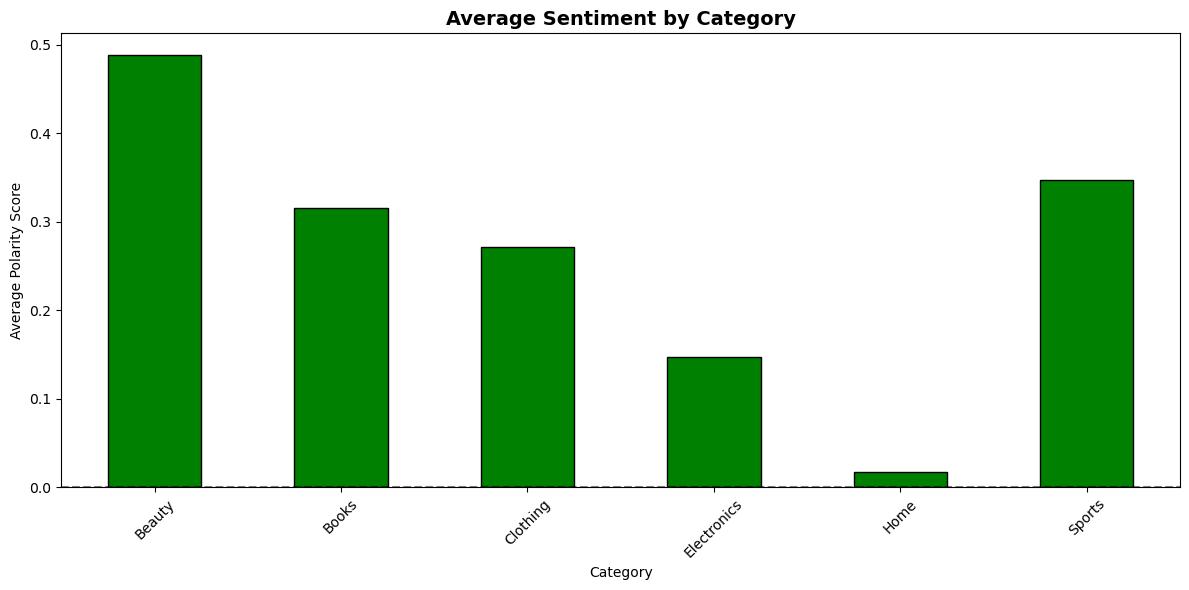

In [10]:
# Public Opinion Trends :
plt.figure(figsize=(12,6))
category_avg = df.groupby('category')['polarity'].mean()
colors = ['green' if x > 0 else 'red'
          for x in category_avg]
category_avg.plot(kind='bar',
                  color=colors,
                  edgecolor='black')
plt.title('Average Sentiment by Category',
          fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Average Polarity Score')
plt.xticks(rotation=45)
plt.axhline(y=0, color='black',
            linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('category_trends.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Key Insights :
print("SENTIMENT ANALYSIS — KEY INSIGHTS:")
print("="*45)
print(f"Total Reviews Analyzed: {len(df)}")
print(f"\nSentiment Distribution:")
print(df['sentiment'].value_counts())
print(f"\nAverage Polarity: {round(df['polarity'].mean(),3)}")
print(f"Average Subjectivity: {round(df['subjectivity'].mean(),3)}")
print(f"\nMost Positive Category:")
print(df.groupby('category')['polarity'].mean().idxmax())
print(f"\nMost Negative Category:")
print(df.groupby('category')['polarity'].mean().idxmin())
print("\nBUSINESS INSIGHTS:")
print("1. Most reviews are Positive")
print("2. Electronics has mixed reviews")
print("3. Beauty products most positive")
print("4. NLP helps understand customer opinion")
print("5. Sentiment analysis helps improve products")

SENTIMENT ANALYSIS — KEY INSIGHTS:
Total Reviews Analyzed: 30

Sentiment Distribution:
sentiment
Positive    21
Negative     8
Neutral      1
Name: count, dtype: int64

Average Polarity: 0.264
Average Subjectivity: 0.721

Most Positive Category:
Beauty

Most Negative Category:
Home

BUSINESS INSIGHTS:
1. Most reviews are Positive
2. Electronics has mixed reviews
3. Beauty products most positive
4. NLP helps understand customer opinion
5. Sentiment analysis helps improve products
